In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

base_path = r"C:\Users\WINDOWS\OneDrive\Documents\Mutual_Fund_Analytics_Project"

processed_path = base_path + r"\data\processed"
charts_path = base_path + r"\reports\charts"

os.makedirs(charts_path, exist_ok=True)

print("Setup completed")

Setup completed


In [5]:
nav = pd.read_csv(processed_path + r"\clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["prev_nav"] = nav.groupby("amfi_code")["nav"].shift(1)

In [8]:
nav.head(10)

,amfi_code,date,nav,prev_nav
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,520.4608
2,100016,2022-01-05,521.7239,515.0971
3,100016,2022-01-06,515.7880,521.7239
4,100016,2022-01-07,515.1639,515.7880
5,100016,2022-01-10,510.7136,515.1639
6,100016,2022-01-11,513.5542,510.7136
7,100016,2022-01-12,512.3195,513.5542
8,100016,2022-01-13,510.2445,512.3195
9,100016,2022-01-14,514.3636,510.2445


In [9]:
nav["daily_return"] = (nav["nav"]/nav["prev_nav"])- 1 

In [10]:
nav.head()

,amfi_code,date,nav,prev_nav,daily_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,515.0971,0.012865
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,515.7880,-0.001210


In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

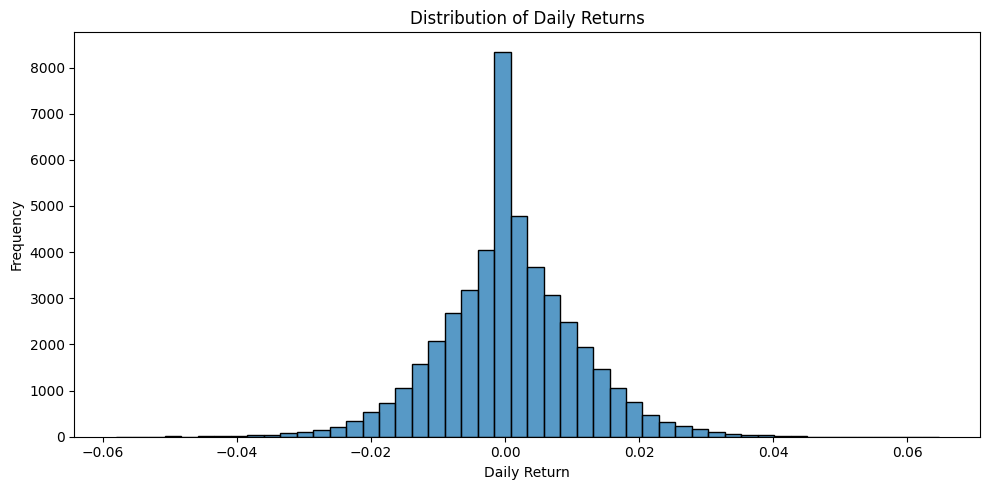

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    charts_path + r"\daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 1: Daily Return Distribution

Daily returns were calculated fund-wise using previous NAV values. The distribution is centered close to 0%, with most returns lying between -2% and +2%. The return profile appears approximately bell-shaped, indicating realistic market behavior and no significant anomalies in NAV data.

In [14]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [15]:
latest_date = nav["date"].max()

one_year_date = latest_date - pd.DateOffset(years=1)

three_year_date = latest_date - pd.DateOffset(years=3)

print(latest_date)
print(one_year_date)
print(three_year_date)

2026-05-29 00:00:00
2025-05-29 00:00:00
2023-05-29 00:00:00
